<a href="https://colab.research.google.com/github/hbisgin/DeepLearning/blob/main/DL_12_CNN4Filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

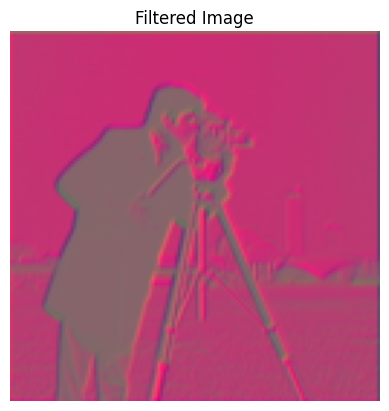

In [12]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

model = nn.Sequential(
    nn.Conv2d(3, 3, kernel_size=3, padding=1),
    nn.ReLU()
)

transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

img = Image.open("/content/drive/MyDrive/DATA/cameraman.jpg").convert("RGB")
x = transform(img).unsqueeze(0)

with torch.no_grad():
    features = model[0](x)

# remove batch dimension
features = features.squeeze(0)

# convert to (H, W, C) for imshow
img_out = features.permute(1,2,0)

# normalize for visualization
img_out = (img_out - img_out.min())/(img_out.max()-img_out.min())

plt.imshow(img_out)
plt.axis("off")
plt.title("Filtered Image")
plt.show()

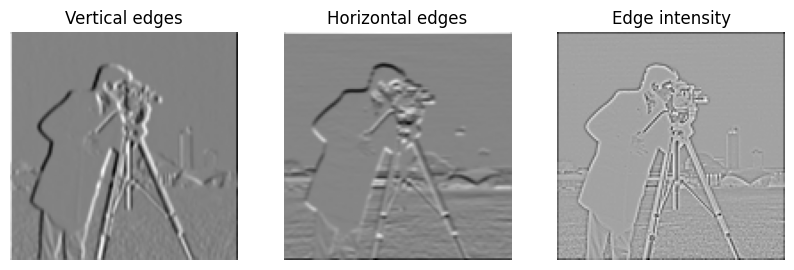

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

# CNN with 3 output channels
model = nn.Sequential(
    nn.Conv2d(3, 3, kernel_size=3, padding=1, bias=False)
)

# Sobel filters
sobel_x = torch.tensor([
[-1, 0, 1],
[-2, 0, 2],
[-1, 0, 1]
], dtype=torch.float32)

sobel_y = torch.tensor([
[-1,-2,-1],
[ 0, 0, 0],
[ 1, 2, 1]
], dtype=torch.float32)

laplace = torch.tensor([
[0, 1, 0],
[1,-4, 1],
[0, 1, 0]
], dtype=torch.float32)

filters = torch.stack([sobel_x, sobel_y, laplace])

# Apply same filter to all RGB channels
weight = torch.zeros(3,3,3,3)

for i in range(3):
    for c in range(3):
        weight[i,c] = filters[i]

model[0].weight.data = weight

# Load image
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor()
])

img = Image.open("/content/drive/MyDrive/DATA/cameraman.jpg").convert("RGB")
x = transform(img).unsqueeze(0)

# Forward pass
with torch.no_grad():
    features = model(x)

features = features.squeeze(0)

# Plot feature maps
plt.figure(figsize=(10,4))

titles = ["Vertical edges", "Horizontal edges", "Edge intensity"]

for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(features[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.show()